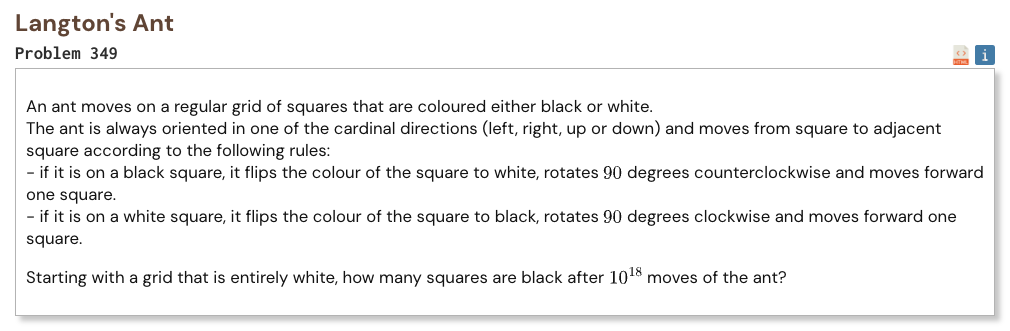

## Initial approach

* simulate the ant only until the highway pattern is reached
* after that point, the movement repeats every fixed number of steps
* in each full highway period, the number of black squares increases by a fixed amount
* compute the remaining huge number of steps using division
* simulate only the leftover steps after full periods
* use a set to store black squares
* no external library is needed

In [1]:
def simulate(steps):
    black = set()
    x = 0
    y = 0
    direction = 0
    moves = [(0, 1), (1, 0), (0, -1), (-1, 0)]

    for _ in range(steps):
        pos = (x, y)

        if pos in black:
            black.remove(pos)
            direction = (direction - 1) % 4
        else:
            black.add(pos)
            direction = (direction + 1) % 4

        dx, dy = moves[direction]
        x += dx
        y += dy

    return len(black)

def solve(target):
    highway_start = 11000
    period = 104
    black_per_period = 12

    base_black = simulate(highway_start)
    remaining = target - highway_start

    full_periods = remaining // period
    leftover = remaining % period

    result = base_black + full_periods * black_per_period
    result += simulate(highway_start + leftover) - base_black

    return result

In [2]:
%%time
result = solve(10 ** 18)
print("Result:", result)

Result: 115384615384614952
CPU times: user 6.33 ms, sys: 198 μs, total: 6.53 ms
Wall time: 6.65 ms
